# BachBot: Unconditioned Chorale Generation and Melody-Conditioned Harmonization

This workbook documents two symbolic music-generation tasks for the assignment: full SATB chorale generation and soprano-conditioned harmonization. It is written to be readable after HTML export, so peer graders do not need to run the code.

## Assignment Tasks Attempted

1. **Symbolic, unconditioned generation**: an autoregressive GRU learns to generate complete SATB time steps.
2. **Symbolic, conditioned generation**: a bidirectional GRU harmonizes a given soprano line with alto, tenor, and bass.

Final generated files:

- `outputs/midi/symbolic_unconditioned.mid`
- `outputs/midi/symbolic_conditioned.mid`

## Dataset and Preprocessing

Dataset source used in this run: **music21 Bach chorales**.

Loaded 371 usable chorales from music21.

Each piece is represented as a fixed-grid matrix with shape `T x 4`, ordered as `[soprano, alto, tenor, bass]`. Values are MIDI pitch tokens plus reserved symbols for `PAD`, `REST`, `HOLD`, `START`, and `END`. The grid size is 0.5 quarter lengths per step.

The training split contains 1107 sequences after training-only transposition augmentation from 260 original training chorales. Validation and test splits are not augmented. Transposition shifts used: `[-5, -3, -2, 0, 2, 3, 5]`.

### Split Summary

<table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>split</th>
      <th>sequences</th>
      <th>avg_steps</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>train</td>
      <td>1107</td>
      <td>99.481</td>
    </tr>
    <tr>
      <td>validation</td>
      <td>56</td>
      <td>99.286</td>
    </tr>
    <tr>
      <td>test</td>
      <td>55</td>
      <td>100.691</td>
    </tr>
  </tbody>
</table>

### Sequence Lengths

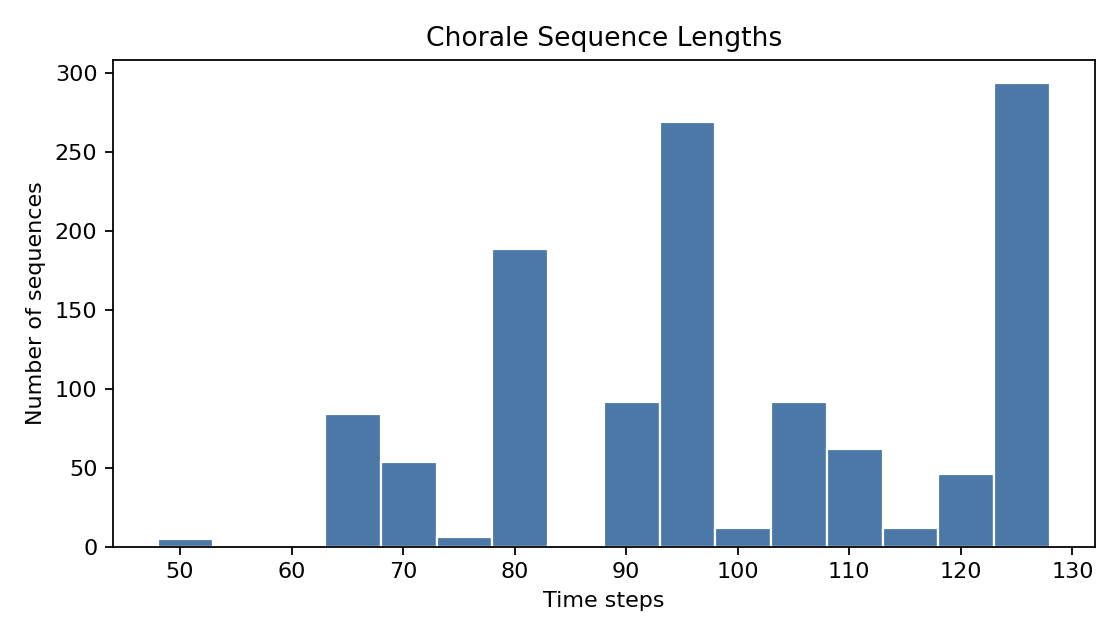

### Voice Ranges

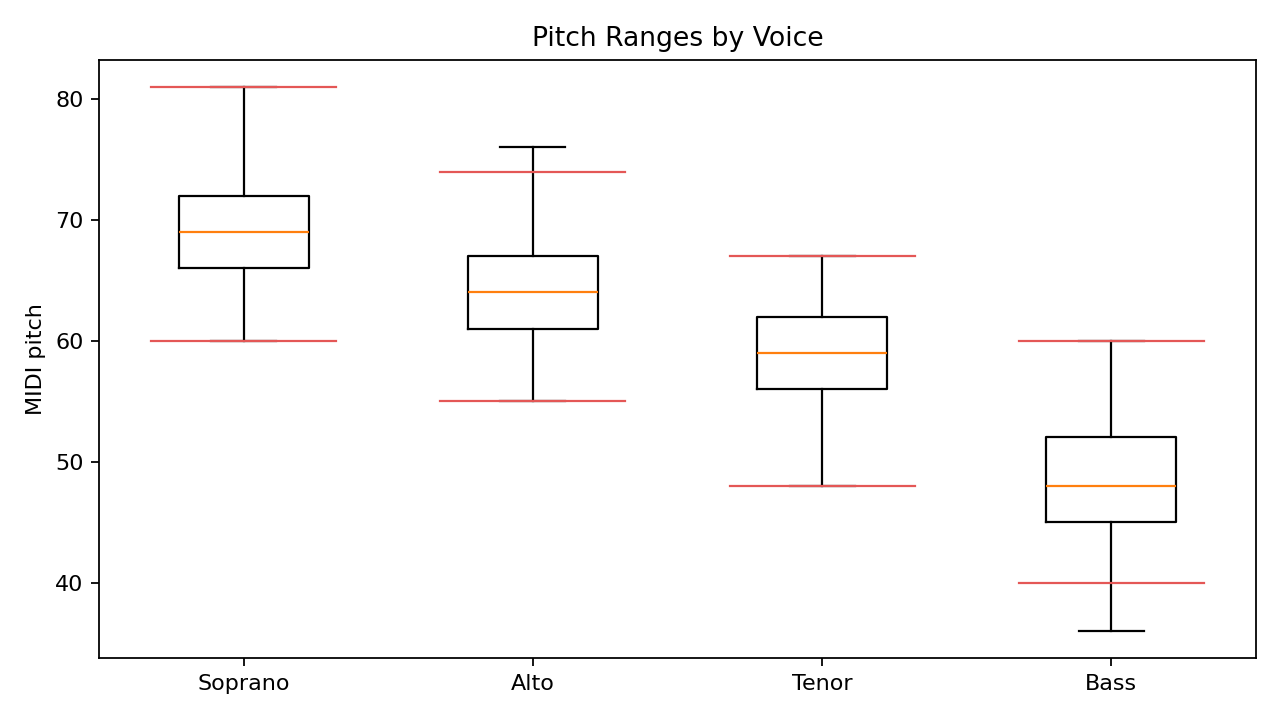

### Pitch-Class Distribution

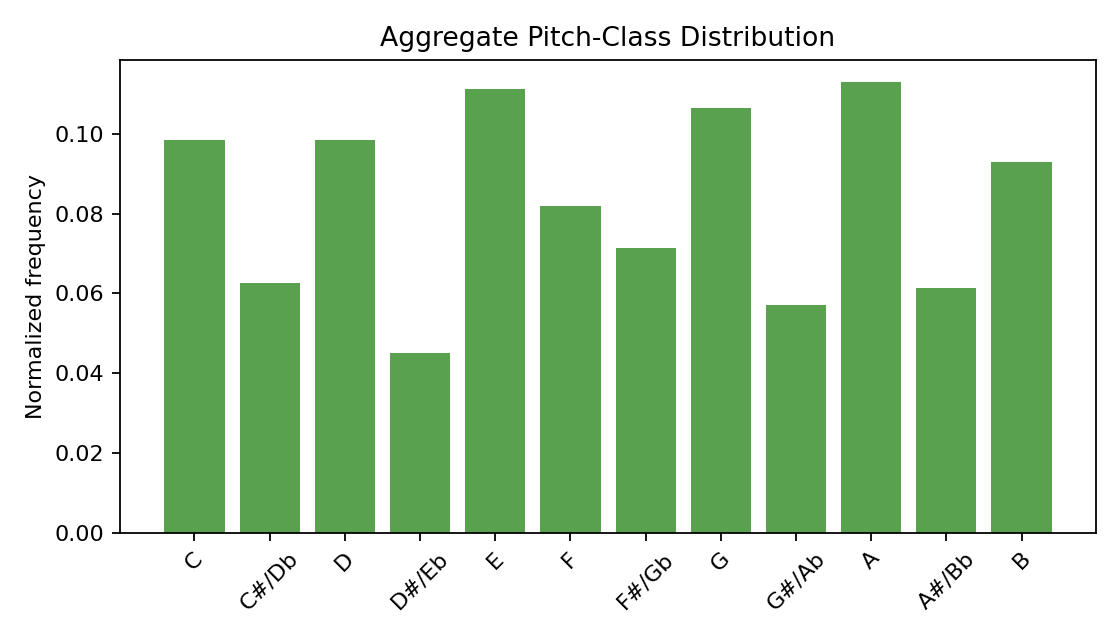

## Tokenization and MIDI Output

The tokenization layer keeps the model vocabulary compact and reversible. MIDI export collapses repeated grid values into longer notes and writes separate tracks for the four voices.

```python
def build_vocab(
    min_pitch: int = 21,
    max_pitch: int = 108,
    special_tokens: list[str] | None = None,
) -> tuple[dict[Any, int], dict[int, Any]]:
    """Return token-to-id and id-to-token dictionaries."""
    specials = special_tokens or SPECIAL_TOKENS
    token_to_id: dict[Any, int] = {}
    for tok in specials:
        token_to_id[tok] = len(token_to_id)
    for pitch in range(min_pitch, max_pitch + 1):
        token_to_id[pitch] = len(token_to_id)
    id_to_token = {idx: tok for tok, idx in token_to_id.items()}
    return token_to_id, id_to_token


```

```python
def satb_matrix_to_midi(
    sequence: np.ndarray,
    output_path: str | Path,
    grid: float = 0.5,
    tempo: int = 90,
    max_note_steps: int | None = 8,
) -> Path:
    """Write a T x 4 SATB pitch matrix as a multi-track MIDI file."""
    output_path = Path(output_path)
    ensure_dir(output_path.parent)
    seq = np.asarray(sequence)
    if seq.ndim != 2 or seq.shape[1] != 4:
        raise ValueError("expected a T x 4 SATB matrix")

    ticks_per_beat = 480
    ticks_per_step = max(1, int(round(ticks_per_beat * grid)))
    midi = MidiFile(ticks_per_beat=ticks_per_beat)

    tempo_track = MidiTrack()
    tempo_track.append(MetaMessage("set_tempo", tempo=bpm2tempo(tempo), time=0))
    tempo_track.append(MetaMessage("time_signature", numerator=4, denominator=4, time=0))
    midi.tracks.append(tempo_track)

    for voice_index, voice_name in enumerate(["soprano", "alto", "tenor", "bass"]):
        track = MidiTrack()
        track.append(MetaMessage("track_name", name=voice_name, time=0))
        track.append(Message("program_change", program=VOICE_PROGRAMS[voice_name], channel=voice_index, time=0))
        silence_ticks = 0
        for pitch, duration_steps in _note_segments(seq[:, voice_index], max_segment_steps=max_note_steps):
            duration_ticks = duration_steps * ticks_per_step
            if pitch is None:
                silence_ticks += duration_ticks
                continue
            velocity = 74 if voice_name in {"soprano", "alto"} else 68
            track.append(Message("note_on", note=int(pitch), velocity=velocity, channel=voice_index, time=silence_ticks))
            track.append(Message("note_off", note=int(pitch), velocity=0, channel=voice_index, time=duration_ticks))
            silence_ticks = 0
        track.append(MetaMessage("end_of_track", time=silence_ticks))
        midi.tracks.append(track)

    midi.save(output_path)
    return output_path


```

## Task 1: Symbolic Unconditioned Generation

The unconditioned task is modeled as next-step prediction over SATB tuples. The baseline is a first-order Markov model over complete four-voice states. The neural model embeds each voice, concatenates the embeddings, processes the sequence with a GRU, and predicts the next soprano, alto, tenor, and bass tokens with separate output heads. For the final output, the GRU generates multiple low-temperature top-k candidates. Each candidate is postprocessed for SATB range/order and reranked with music-theory-inspired badness scores.

```python
class SATBGRULanguageModel(nn.Module):
    """Autoregressive GRU for unconditioned SATB generation."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_dim: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
        pad_id: int = 0,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.gru = nn.GRU(
            input_size=embedding_dim * 4,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.heads = nn.ModuleList([nn.Linear(hidden_dim, vocab_size) for _ in range(4)])

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        embeddings = [self.embedding(x[:, :, voice]) for voice in range(4)]
        combined = torch.cat(embeddings, dim=-1)
        hidden, _ = self.gru(combined)
        return tuple(head(hidden) for head in self.heads)


```

### Task 1 Training Curve

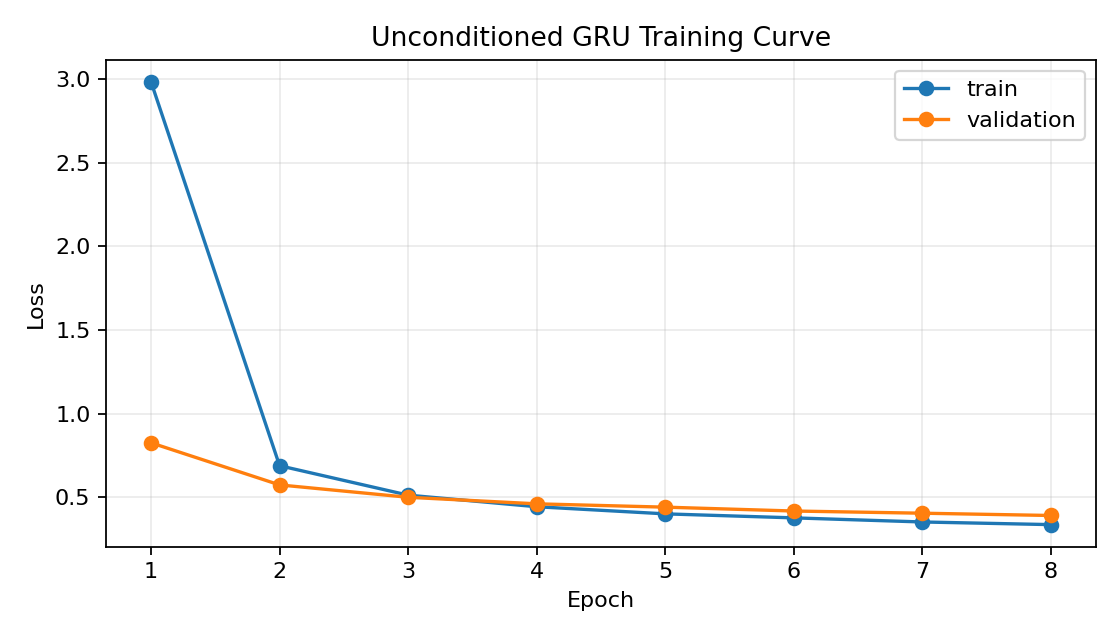

### Task 1 Evaluation

<table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>model</th>
      <th>test_loss</th>
      <th>perplexity</th>
      <th>range_violations</th>
      <th>voice_crossings</th>
      <th>strong_beat_consonance</th>
      <th>repeated_note_ratio</th>
      <th>chord_diversity</th>
      <th>parallel_fifths_octaves</th>
      <th>cadence_score</th>
      <th>pitch_class_hist_distance</th>
      <th>notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Markov baseline</td>
      <td>0.337</td>
      <td>1.401</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.833</td>
      <td>0.750</td>
      <td>1.000</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>1.353</td>
      <td>first-order SATB tuple transitions</td>
    </tr>
    <tr>
      <td>GRU + postprocess + rerank</td>
      <td>0.344</td>
      <td>1.090</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.792</td>
      <td>0.453</td>
      <td>0.812</td>
      <td>2.0</td>
      <td>1.0</td>
      <td>0.377</td>
      <td>best of 30 top-k temperature samples</td>
    </tr>
  </tbody>
</table>

### Task 1 Candidate Reranking

The final unconditioned MIDI is selected from multiple GRU samples. Lower badness is better; the score combines range, crossing, dissonance, leap, repetition, pitch-distribution, diversity, and cadence terms.

<table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>candidate</th>
      <th>badness</th>
      <th>range_violation_rate</th>
      <th>voice_crossing_rate</th>
      <th>large_leap_rate</th>
      <th>strong_beat_dissonance_rate</th>
      <th>parallel_fifths_octaves_rate</th>
      <th>repetition_penalty</th>
      <th>chord_diversity</th>
      <th>cadence_score</th>
      <th>pitch_histogram_distance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>22.0</td>
      <td>-1.536</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.013</td>
      <td>0.208</td>
      <td>0.021</td>
      <td>0.0</td>
      <td>0.812</td>
      <td>1.0</td>
      <td>0.377</td>
    </tr>
    <tr>
      <td>13.0</td>
      <td>-1.492</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.011</td>
      <td>0.118</td>
      <td>0.074</td>
      <td>0.0</td>
      <td>0.740</td>
      <td>1.0</td>
      <td>0.410</td>
    </tr>
    <tr>
      <td>10.0</td>
      <td>-1.441</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.003</td>
      <td>0.188</td>
      <td>0.084</td>
      <td>0.0</td>
      <td>0.823</td>
      <td>1.0</td>
      <td>0.340</td>
    </tr>
    <tr>
      <td>9.0</td>
      <td>-1.398</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.003</td>
      <td>0.167</td>
      <td>0.084</td>
      <td>0.0</td>
      <td>0.833</td>
      <td>1.0</td>
      <td>0.430</td>
    </tr>
    <tr>
      <td>27.0</td>
      <td>-1.360</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.011</td>
      <td>0.181</td>
      <td>0.032</td>
      <td>0.0</td>
      <td>0.781</td>
      <td>1.0</td>
      <td>0.565</td>
    </tr>
    <tr>
      <td>25.0</td>
      <td>-1.328</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.003</td>
      <td>0.194</td>
      <td>0.074</td>
      <td>0.0</td>
      <td>0.823</td>
      <td>1.0</td>
      <td>0.471</td>
    </tr>
    <tr>
      <td>21.0</td>
      <td>-1.326</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.003</td>
      <td>0.167</td>
      <td>0.084</td>
      <td>0.0</td>
      <td>0.812</td>
      <td>1.0</td>
      <td>0.492</td>
    </tr>
    <tr>
      <td>11.0</td>
      <td>-1.283</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.000</td>
      <td>0.285</td>
      <td>0.032</td>
      <td>0.0</td>
      <td>0.833</td>
      <td>1.0</td>
      <td>0.470</td>
    </tr>
    <tr>
      <td>18.0</td>
      <td>-1.273</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.003</td>
      <td>0.215</td>
      <td>0.053</td>
      <td>0.0</td>
      <td>0.844</td>
      <td>1.0</td>
      <td>0.558</td>
    </tr>
    <tr>
      <td>15.0</td>
      <td>-1.204</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.000</td>
      <td>0.208</td>
      <td>0.084</td>
      <td>0.0</td>
      <td>0.729</td>
      <td>1.0</td>
      <td>0.492</td>
    </tr>
  </tbody>
</table>

### Task 1 Metric Comparison

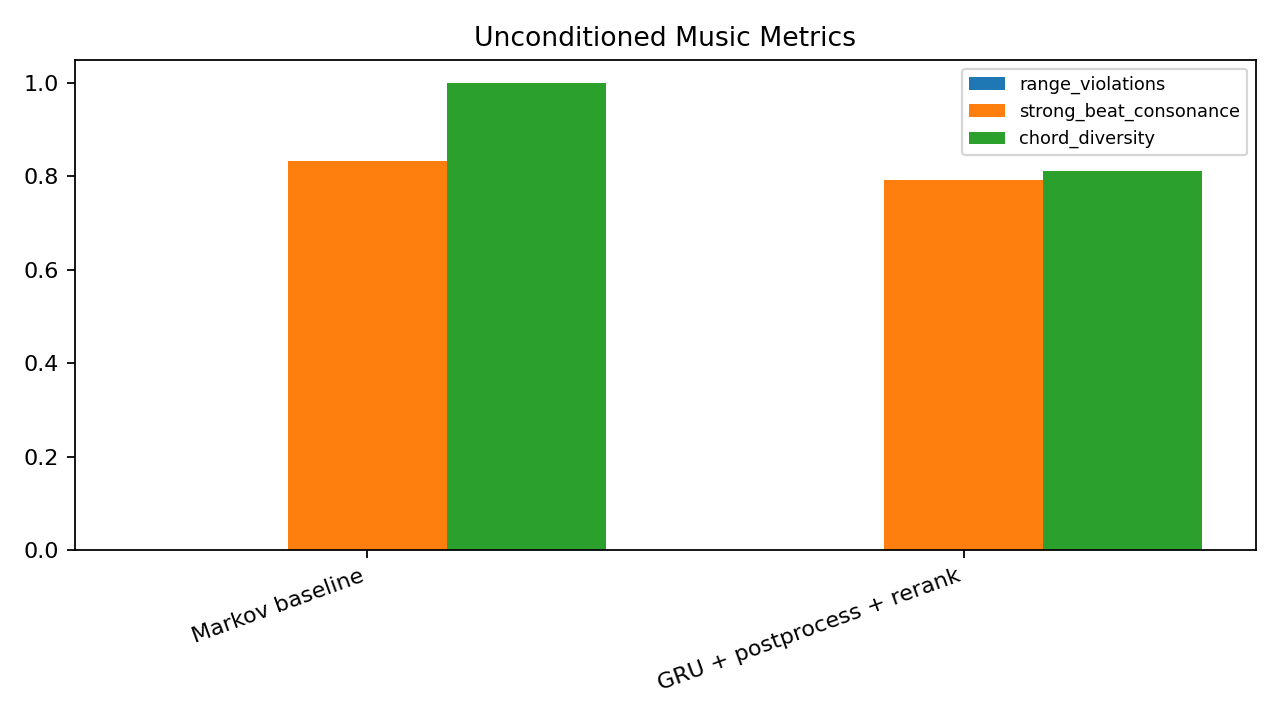

## Task 2: Soprano-Conditioned Harmonization

For conditioned generation, the full soprano melody is known in advance. The baseline predicts the most common lower-voice chord for a soprano pitch class and beat position, with backoff to pitch-class-only and global counts. The neural model uses a bidirectional GRU over the soprano sequence and predicts alto, tenor, and bass at every time step. Instead of choosing each lower voice independently, the upgraded decoder uses beam search with a model-score plus musical-penalty objective. The final MIDI demo uses a short custom soprano melody so the conditioned sample is musically varied; held-out test data is still used for the reported accuracy metrics.

```python
class LookupHarmonizationBaseline:
    """Predict lower voices from soprano pitch class and beat position."""

    def __init__(self, id_to_token: dict[int, Any], pad_id: int = 0, steps_per_measure: int = 8) -> None:
        self.id_to_token = id_to_token
        self.pad_id = pad_id
        self.steps_per_measure = steps_per_measure
        self.by_pc_beat: dict[tuple[Any, int], Counter] = defaultdict(Counter)
        self.by_pc: dict[Any, Counter] = defaultdict(Counter)
        self.global_counts: Counter = Counter()

    def _pitch_class(self, token_id: int) -> Any:
        token = self.id_to_token[int(token_id)]
        return int(token) % 12 if isinstance(token, int) else token

    def fit(self, sequences: list[np.ndarray]) -> "LookupHarmonizationBaseline":
        for seq in sequences:
            arr = np.asarray(seq)
            for t, row in enumerate(arr):
                if np.any(row == self.pad_id):
                    continue
                pc = self._pitch_class(int(row[0]))
                lower = tuple(map(int, row[1:4]))
                beat = t % self.steps_per_measure
                self.by_pc_beat[(pc, beat)][lower] += 1
                self.by_pc[pc][lower] += 1
                self.global_counts[lower] += 1
        return self

    @staticmethod
    def _most_common(counter: Counter) -> tuple[int, int, int]:
        return tuple(counter.most_common(1)[0][0])

    def predict(self, soprano_sequence: np.ndarray) -> np.ndarray:
        soprano = np.asarray(soprano_sequence)
        if soprano.ndim == 2:
            soprano = soprano[:, 0]
        output = np.full((len(soprano), 4), self.pad_id, dtype=np.int64)
        output[:, 0] = soprano
        for t, token_id in enumerate(soprano):
            pc = self._pitch_class(int(token_id))
            beat = t % self.steps_per_measure
            if self.by_pc_beat.get((pc, beat)):
                lower = self._most_common(self.by_pc_beat[(pc, beat)])
            elif self.by_pc.get(pc):
                lower = self._most_common(self.by_pc[pc])
            else:
                lower = self._most_common(self.global_counts)
            output[t, 1:4] = lower
        return output

    def score(self, sequences: list[np.ndarray]) -> dict[str, float]:
        correct = np.zeros(3, dtype=np.float64)
        total = 0.0
        exact = 0.0
        for seq in sequences:
            arr = np.asarray(seq)
            pred = self.predict(arr[:, 0])
            mask = ~np.any(arr == self.pad_id, axis=1)
            for row_true, row_pred in zip(arr[mask], pred[mask]):
                matches = row_true[1:4] == row_pred[1:4]
                correct += matches.astype(np.float64)
                exact += float(np.all(matches))
                total += 1.0
        total = max(total, 1.0)
        return {
            "alto_accuracy": float(correct[0] / total),
            "tenor_accuracy": float(correct[1] / total),
            "bass_accuracy": float(correct[2] / total),
            "average_voice_accuracy": float(correct.mean() / total),
            "exact_atb_accuracy": float(exact / total),
        }

```

```python
class SopranoConditionedHarmonizer(nn.Module):
    """Bidirectional GRU that predicts alto, tenor, and bass from soprano."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_dim: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
        bidirectional: bool = True,
        pad_id: int = 0,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        factor = 2 if bidirectional else 1
        self.heads = nn.ModuleList([nn.Linear(hidden_dim * factor, vocab_size) for _ in range(3)])

    def forward(self, soprano: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        embedded = self.embedding(soprano)
        hidden, _ = self.gru(embedded)
        return tuple(head(hidden) for head in self.heads)

```

```python
def harmonize_with_beam_search(
    model: torch.nn.Module,
    soprano_sequence: np.ndarray,
    allowed_ids_by_voice: dict[str, list[int]],
    id_to_token: dict[int, Any],
    device: torch.device,
    beam_size: int = 8,
    top_k_per_voice: int = 5,
    rule_weight: float = 1.0,
    steps_per_measure: int = 8,
) -> np.ndarray:
    """Generate lower voices conditioned on soprano using model score plus SATB penalties."""
    model.eval()
    soprano_tokens = np.asarray(soprano_sequence, dtype=np.int64)
    soprano_tensor = torch.as_tensor(soprano_tokens, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        alto_logits, tenor_logits, bass_logits = model(soprano_tensor)

    beams: list[tuple[float, list[list[int]]]] = [(0.0, [])]
    voice_options = [
        ("alto", alto_logits.detach().cpu()[0]),
        ("tenor", tenor_logits.detach().cpu()[0]),
        ("bass", bass_logits.detach().cpu()[0]),
    ]
    for t, soprano_token in enumerate(soprano_tokens):
        options_per_voice = [
            _top_allowed_log_probs(logits[t], allowed_ids_by_voice[voice_name], top_k_per_voice)
            for voice_name, logits in voice_options
        ]
        expanded: list[tuple[float, list[list[int]]]] = []
        for score, states in beams:
            previous = states[-1] if states else None
            for alto, tenor, bass in product(*options_per_voice):
                chord = [int(soprano_token), alto[0], tenor[0], bass[0]]
                neg_log_prob = -(alto[1] + tenor[1] + bass[1])
                penalty = chord_penalty(
                    chord,
                    previous_chord=previous,
                    beat_index=t,
                    id_to_token=id_to_token,
                    steps_per_measure=steps_per_measure,
                )
                expanded.append((score + neg_log_prob + rule_weight * penalty, states + [chord]))
        expanded.sort(key=lambda item: item[0])
        beams = expanded[:beam_size]
    return np.asarray(beams[0][1], dtype=np.int64)


```

### Task 2 Training Curve

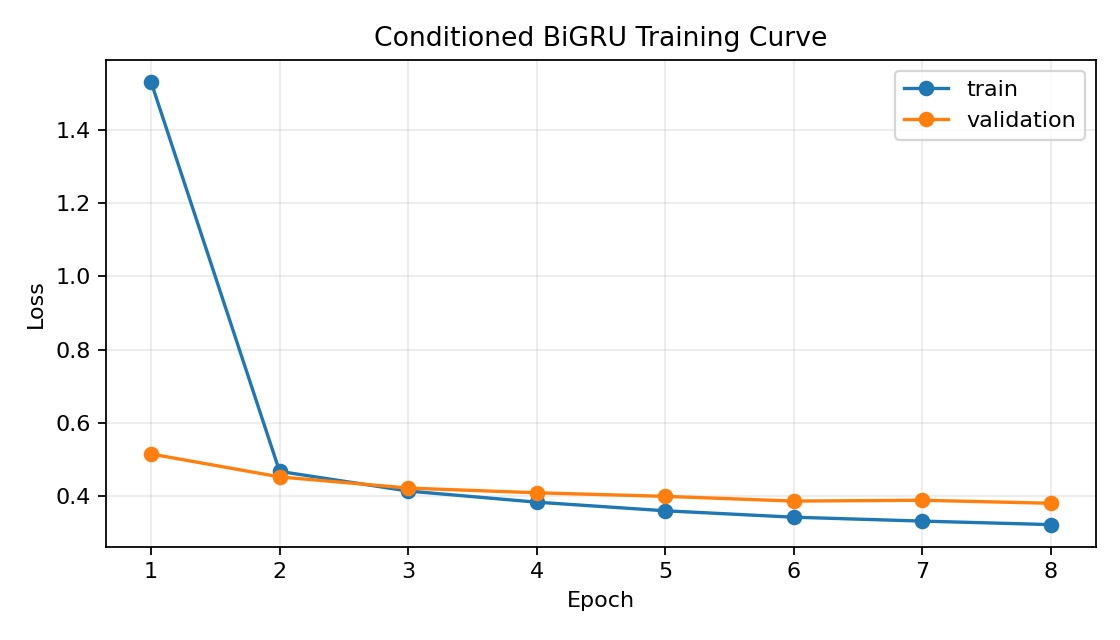

### Task 2 Evaluation

<table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>model</th>
      <th>alto_accuracy</th>
      <th>tenor_accuracy</th>
      <th>bass_accuracy</th>
      <th>average_voice_accuracy</th>
      <th>exact_atb_accuracy</th>
      <th>range_violations</th>
      <th>voice_crossings</th>
      <th>strong_beat_consonance</th>
      <th>repeated_note_ratio</th>
      <th>chord_diversity</th>
      <th>parallel_fifths_octaves</th>
      <th>cadence_score</th>
      <th>pitch_class_hist_distance</th>
      <th>notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Lookup baseline</td>
      <td>0.953</td>
      <td>0.950</td>
      <td>0.959</td>
      <td>0.954</td>
      <td>0.943</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.969</td>
      <td>0.516</td>
      <td>0.141</td>
      <td>39.0</td>
      <td>0.4</td>
      <td>0.456</td>
      <td>soprano pitch-class plus beat-position lookup</td>
    </tr>
    <tr>
      <td>BiGRU model</td>
      <td>0.054</td>
      <td>0.047</td>
      <td>0.052</td>
      <td>0.051</td>
      <td>0.032</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.948</td>
      <td>0.575</td>
      <td>0.359</td>
      <td>2.0</td>
      <td>0.4</td>
      <td>0.931</td>
      <td>bidirectional GRU with beam search and SATB rule penalties</td>
    </tr>
  </tbody>
</table>

### Task 2 Metric Comparison

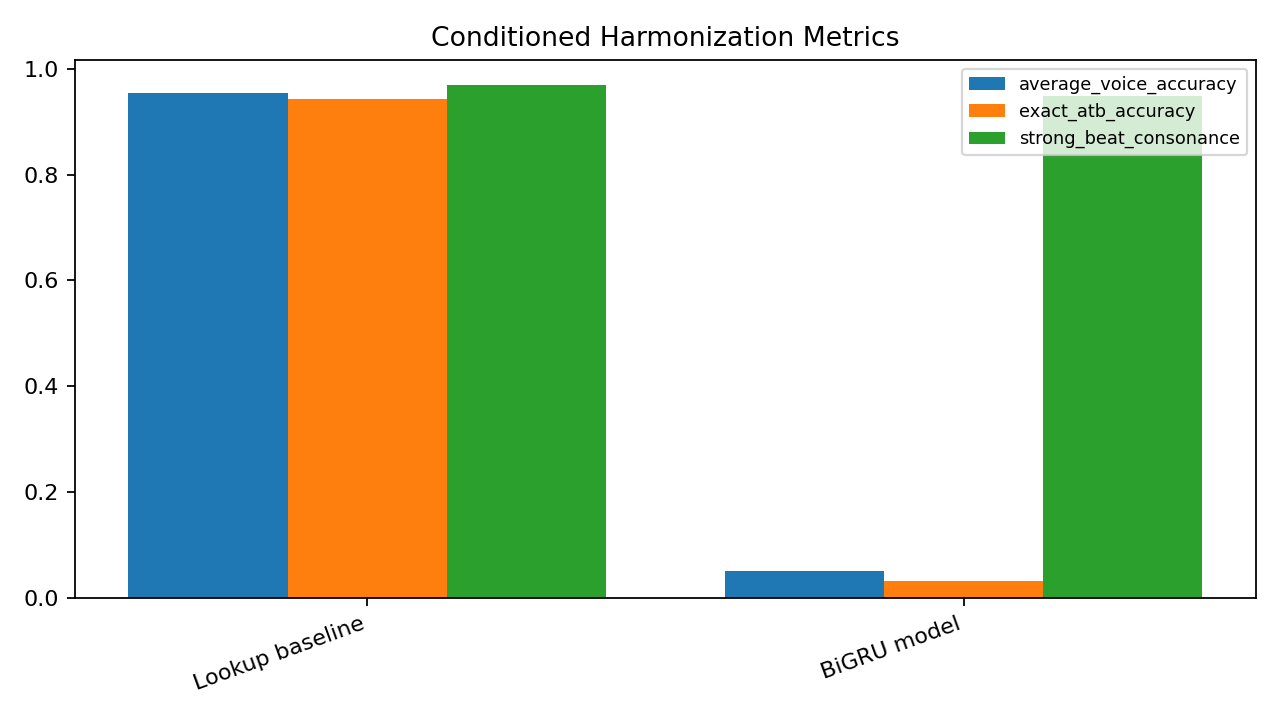

### DeepBach-Inspired Gibbs Demo

Because DeepBach is especially relevant to Bach chorale harmonization, the final conditioned MIDI also includes a lightweight DeepBach-inspired Gibbs sampler. It learns local conditional distributions from the real Bach chorale corpus, keeps the soprano melody fixed, and repeatedly resamples the lower voices using Bach-trained context plus simple voice-leading constraints. This is not the pretrained official DeepBach model; it is a local class-project implementation in the same spirit.

<table class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>model</th>
      <th>alto_accuracy</th>
      <th>tenor_accuracy</th>
      <th>bass_accuracy</th>
      <th>average_voice_accuracy</th>
      <th>exact_atb_accuracy</th>
      <th>range_violations</th>
      <th>voice_crossings</th>
      <th>strong_beat_consonance</th>
      <th>repeated_note_ratio</th>
      <th>chord_diversity</th>
      <th>parallel_fifths_octaves</th>
      <th>cadence_score</th>
      <th>pitch_class_hist_distance</th>
      <th>notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>DeepBach-inspired Gibbs</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.444</td>
      <td>0.359</td>
      <td>2.0</td>
      <td>0.4</td>
      <td>0.396</td>
      <td>Gibbs sampler over Bach-trained local conditional distributions</td>
    </tr>
  </tbody>
</table>

```python
class DeepBachGibbsSampler:
    """A small DeepBach-inspired Gibbs sampler trained from local chorales.

    DeepBach samples notes from conditional distributions given the rest of a
    chorale. This class keeps that spirit while staying lightweight: it learns
    empirical conditionals over soprano, beat position, vertical sonorities,
    and left/right SATB context, then repeatedly resamples lower voices.
    """

    def __init__(
        self,
        token_to_id: dict[Any, int],
        id_to_token: dict[int, Any],
        pad_id: int,
        steps_per_measure: int = 8,
        seed: int = 42,
        smoothing: float = 0.1,
    ) -> None:
        self.token_to_id = token_to_id
        self.id_to_token = id_to_token
        self.pad_id = pad_id
        self.steps_per_measure = steps_per_measure
        self.seed = seed
        self.smoothing = smoothing
        self.state_counts: Counter[tuple[int, int, int, int]] = Counter()
        self.transition_counts: dict[tuple[int, int, int, int], Counter] = defaultdict(Counter)
        self.lower_by_soprano_beat: dict[tuple[int, int], Counter] = defaultdict(Counter)
        self.lower_by_soprano: dict[int, Counter] = defaultdict(Counter)
        self.lower_by_pc_beat: dict[tuple[int, int], Counter] = defaultdict(Counter)
        self.lower_by_pc: dict[int, Counter] = defaultdict(Counter)
        self.global_lower: Counter[tuple[int, int, int]] = Counter()

    def _pitch(self, token_id: int) -> int | None:
        token = self.id_to_token[int(token_id)]
        return int(token) if isinstance(token, int) else None

    def _pc(self, token_id: int) -> int:
        pitch = self._pitch(token_id)
        return 0 if pitch is None else pitch % 12

    def _nearest_token_for_pc(self, pc: int, target: int, low: int, high: int, ceiling: int | None = None) -> int | None:
        if ceiling is not None:
            high = min(high, ceiling)
        candidates = [
            pitch
            for pitch in range(low, high + 1)
            if pitch % 12 == pc and pitch in self.token_to_id
        ]
        if not candidates:
            return None
        pitch = min(candidates, key=lambda p: (abs(p - target), abs(p - (low + high) / 2)))
        return int(self.token_to_id[pitch])

    def fit(self, sequences: list[np.ndarray]) -> "DeepBachGibbsSampler":
        """Learn empirical conditionals from tokenized SATB sequences."""
        for seq in sequences:
            arr = np.asarray(seq, dtype=np.int64)
            rows = [tuple(map(int, row)) for row in arr if not np.any(row == self.pad_id)]
            self.state_counts.update(rows)
            for prev, curr in zip(rows[:-1], rows[1:]):
                self.transition_counts[prev][curr] += 1
            for t, row in enumerate(rows):
                soprano = row[0]
                lower = row[1:4]
                beat = t % self.steps_per_measure
                pc = self._pc(soprano)
                self.lower_by_soprano_beat[(soprano, beat)][lower] += 1
                self.lower_by_soprano[soprano][lower] += 1
                self.lower_by_pc_beat[(pc, beat)][lower] += 1
                self.lower_by_pc[pc][lower] += 1
                self.global_lower[lower] += 1
        return self

    def _log_counter_prob(self, counter: Counter, item: tuple[int, ...], vocab_size: int) -> float:
        total = sum(counter.values())
        return math.log((counter[item] + self.smoothing) / (total + self.smoothing * max(1, vocab_size)))

    def _reasonable_lower(self, soprano: int, lower: tuple[int, int, int], beat: int) -> bool:
        pitches = [self._pitch(token_id) for token_id in (soprano, *lower)]
        if any(p is None for p in pitches):
            return False
        soprano_pitch, alto, tenor, bass = [int(p) for p in pitches if p is not None]
        if not (soprano_pitch >= alto >= tenor >= bass):
            return False
        for voice, pitch in zip(VOICE_NAMES, [soprano_pitch, alto, tenor, bass]):
            low, high = VOICE_RANGES[voice]
            if pitch < low or pitch > high:
                return False
        strong_beat = beat in {0, self.steps_per_measure // 2}
        if strong_beat:
```

## Evaluation Design

The ML metrics measure predictive fit: validation/test loss for both neural models, perplexity for the unconditioned model, and per-voice plus exact lower-voice accuracy for harmonization. Because musical quality is not captured by likelihood alone, the project also reports voice range violations, voice crossings, consonance on strong beats, repeated-note ratio, chord diversity, parallel perfect fifths/octaves, pitch-class histogram distance, and a simple cadence heuristic.

```python
def voice_range_violation_rate(sequence: np.ndarray, voice_ranges: dict[str, tuple[int, int]] | None = None) -> float:
    """Return the fraction of notes outside approximate human SATB ranges."""
    ranges = voice_ranges or VOICE_RANGES
    total = 0
    bad = 0
    for voice_index, voice_name in enumerate(["soprano", "alto", "tenor", "bass"]):
        low, high = ranges[voice_name]
        for value in np.asarray(sequence)[:, voice_index]:
            pitch = _pitch_or_none(value)
            if pitch is None:
                continue
            total += 1
            bad += int(pitch < low or pitch > high)
    return bad / total if total else 0.0


def voice_crossing_count(sequence: np.ndarray) -> int:
    """Count time steps where SATB ordering is violated."""
    count = 0
    for row in _valid_rows(sequence):
        soprano, alto, tenor, bass = row
        if alto > soprano:
            count += 1
        if tenor > alto:
            count += 1
        if bass > tenor:
            count += 1
    return count


def consonance_rate(sequence: np.ndarray, strong_beat_mask: np.ndarray | None = None) -> float:
    """Estimate the fraction of vertical intervals that are consonant."""
    seq = np.asarray(sequence)
    total = 0
    consonant = 0
    if strong_beat_mask is None:
        mask = np.ones(seq.shape[0], dtype=bool)
    else:
        mask = np.asarray(strong_beat_mask, dtype=bool)
    for row, keep in zip(seq, mask):
        if not keep:
            continue
        pitches = [_pitch_or_none(v) for v in row]
        pitches = [p for p in pitches if p is not None]
        for a, b in combinations(pitches, 2):
            total += 1
            consonant += int(abs(a - b) % 12 in CONSONANT_INTERVALS)
    return consonant / total if total else 0.0


def repeated_note_ratio(sequence: np.ndarray) -> float:
    """Return the fraction of adjacent same-voice notes that repeat."""
    seq = np.asarray(sequence)
    repeated = 0
    total = 0
    for voice_index in range(seq.shape[1]):
        previous = None
        for value in seq[:, voice_index]:
            pitch = _pitch_or_none(value)
            if pitch is None:
                previous = None
                continue
            if previous is not None:
                total += 1
                repeated += int(previous == pitch)
            previous = pitch
    return repeated / total if total else 0.0


def chord_diversity(sequence: np.ndarray) -> float:
    """Return unique SATB sonority ratio."""
    rows = [tuple(row) for row in _valid_rows(sequence)]
    return len(set(rows)) / len(rows) if rows else 0.0


def parallel_fifths_octaves(sequence: np.ndarray) -> int:
    """Heuristically count parallel perfect fifths and octaves."""
    rows = _valid_rows(sequence)
    count = 0
    for prev, curr in zip(rows[:-1], rows[1:]):
        for i, j in combinations(range(4), 2):
            prev_interval = abs(prev[i] - prev[j]) % 12
            curr_interval = abs(curr[i] - curr[j]) % 12
            if prev_interval not in PERFECT_INTERVALS or curr_interval not in PERFECT_INTERVALS:
                continue
            motion_i = curr[i] - prev[i]
            motion_j = curr[j] - prev[j]
            if motion_i == 0 or motion_j == 0:
                continue
            if (motion_i > 0 and motion_j > 0) or (motion_i < 0 and motion_j < 0):
                count += 1
    return count


def pitch_class_histogram(sequence: np.ndarray) -> np.ndarray:
    """Return a normalized 12-bin pitch-class histogram."""
    hist = np.zeros(12, dtype=np.float64)
    for value in np.asarray(sequence).reshape(-1):
        pitch = _pitch_or_none(value)
        if pitch is not None:
            hist[pitch % 12] += 1.0
    total = hist.sum()
    return hist / total if total else hist


def histogram_distance(hist_a: np.ndarray, hist_b: np.ndarray) -> float:
    """Return L1 distance between normalized pitch-class histograms."""
    return float(np.abs(np.asarray(hist_a) - np.asarray(hist_b)).sum())


```

## Related Work

**DeepBach** is directly relevant because it models Bach chorales and supports generation and harmonization. Our implementation is intentionally smaller: a compact grid representation, lightweight GRU models, and a classroom-scale training pipeline.

**Music Transformer** is a broader symbolic music-generation reference point. Its self-attention mechanism can model longer-range structure than a small GRU, but it is more expensive and less necessary for this minimum viable chorale pipeline.

Bach chorales are a common benchmark because they are compact, symbolic, four-voice, harmonically regular, and interpretable using both ML metrics and music-theory-inspired heuristics.

## Limitations and Future Work

- The eighth-note grid is simple and loses some expressive rhythmic detail.
- The neural models are deliberately small; longer training and attention-based models could improve global form.
- Voice-leading metrics are heuristics, not substitutes for human listening.
- This final run uses the real `music21` Bach chorale corpus, but parsing SATB voices from symbolic scores is still approximate.

Useful extensions include rule-based postprocessing, temperature comparisons, custom melody harmonization, and optional MIDI-to-MP3 rendering for easier presentation playback.

## Reproducibility

Run the full pipeline with:

```bash
python3 scripts/run_all.py --config configs/mvp.yaml
```

The command rebuilds the dataset, EDA figures, model checkpoints, metric tables, MIDI files, notebook HTML, and the `submission/` folder.